## Spectral Distribution Visualization

In [245]:
import os
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Optional, List, Tuple

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

data_path = Path(f'../Spectrometer')

## Dataset Abstract Object

In [48]:
class Dataset(ABC):

    @abstractmethod
    def __len__(self):
        raise NotImplementedError()

    @abstractmethod
    def __getitem__(self, index):
        raise NotImplementedError()


if __name__ == '__main__':
    print(f'Testing Abstract Dataset')

    try:
        dataset = Dataset()
        assert Fasle, f'Cannot created from abstract class'

    except:
        pass

    print(f'Test passed')

Testing Abstract Dataset
Test passed


## Spectral Dataloader

In [109]:
class Custom_Dataset(Dataset):

    def __init__(self, root_dir):
        self.specimens_hash = {}


        for week in os.listdir(root_dir):
            week_dir = os.path.join(root_dir, week);

            for plant_cat in os.listdir(week_dir):
                plant_cat_dir = os.path.join(week_dir, plant_cat);

                for class_type in os.listdir(plant_cat_dir):
                    class_type_dir = os.path.join(plant_cat_dir, class_type)

                for r_macro in os.listdir(class_type_dir):
                    r_macro_dir = os.path.join(class_type_dir, r_macro);

                    for point_data in os.listdir(r_macro_dir):
                        point_data_dir = os.path.join(r_macro_dir, point_data);

                        for specimen_data in os.listdir(point_data_dir):
                            self.map_file_hash(point_data_dir, specimen_data);

            self.specimen_indices = list(self.specimens_hash.keys())
            assert len(self.specimen_indices) == len(self), f"Incompatible shaped detectected during dataloading"

    def map_file_hash(self, parent_path, specimen_data_pth):
        name = None

        assert "." in specimen_data_pth, f"No file tyde identifier detected"
        if "_" in specimen_data_pth:
            name = specimen_data_pth.split("_")[0];
        else:
            name = specimen_data_pth.split(".")[0];
        
        specimen_ful_path = os.path.join(parent_path, specimen_data_pth);

        if name not in self.specimens_hash:
            self.specimens_hash[name] = {"raw": None, "calculations": None, "img": None};

        if specimen_data_pth.endswith("csv"):
            if "calculations" in specimen_data_pth:
                self.specimens_hash[name]["calculations"] = specimen_ful_path;
            else:
                self.specimens_hash[name]["raw"] = specimen_ful_path;

        elif specimen_data_pth.endswith("png"):
            self.specimens_hash[name]["img"] = specimen_ful_path;

        else:
            raise ValueError("Unsupported file format")


    def get_label(self, index):
        assert 0<= index <= len(self), f'Index out of range min({0}, max({len(self)}))'
        return self.specimen_indices[index]
            

    def __len__(self):
        return len(self.specimens_hash)

    @staticmethod
    def clean_cols(df):
        return df.columns.str.strip().str.lower().str.replace(' ', '_')

    @staticmethod
    def convert_cols(df):
        cols = df.columns
        no_cols = len(cols)
        for i in range(no_cols):
            idx = -(i + 1)
            if idx == -1:
                df[cols[idx]] = df.iloc[:, idx].str.replace("%", "").astype(np.float32)
            else:
                df[cols[idx]] = df.iloc[:, idx].astype(np.float64)  
        return df        


    def __getitem__(self, index):
        assert 0 <= index <= len(self) or index > -len(self) , f"Index out of range max upper bound is {len(self)}"
        indexed_key = self.specimen_indices[index]
        data_sub_dict = self.specimens_hash[indexed_key]

        actual_readings = pd.read_csv(data_sub_dict['raw'], skiprows=6, nrows=3648);
        # peak_values = pd.read_csv(data_sub_dict['raw'], skiprows=3657, nrows=4)
        calibration_values = pd.read_csv(data_sub_dict['raw'], skiprows=3662)

        actual_readings.columns = Custom_Dataset.clean_cols(actual_readings)
        calibration_values.columns = Custom_Dataset.clean_cols(calibration_values)

        actual_readings = Custom_Dataset.convert_cols(actual_readings)
        return actual_readings, calibration_values, data_sub_dict



if __name__ == "__main__":
    print("Testing Custom Dataset Loader")
    
    dataset = Custom_Dataset(data_path);
    assert len(set(spec_dataset.specimens_hash.keys())) == len(dataset), f"Incompatible data length"

    success_loads = 0
    failed_loads = 0
    for i in range(len(dataset)):
        try:
            loaded_ = dataset[i]
            success_loads += 1
        except:
            failed_loads += 1
            continue

    print(f"\nLOADING REPORT\n{'='*15}\nTotal successful loads:\t{success_loads}\nTotal Failed loads:\t{failed_loads}\nTotal loads:\t\
    {success_loads+failed_loads}\n")
    assert success_loads + failed_loads == len(dataset), f'Incosistence in dataloading'

    print("Test passed")
  

Testing Custom Dataset Loader

LOADING REPORT
Total successful loads:	237
Total Failed loads:	3
Total loads:	    240

Test passed


## Data Loader ABT

In [51]:
class Dataloader(ABC):

    @abstractmethod
    def __iter__(self):
        raise NotImplementedError()

if __name__ == '__main__':
    print("Testing Dataloader ABT")
    try:
        dataloader = Dataloader()
        assert False, f"Cannot create from an ABT"
    except:
        pass

    print("Test passed")

Testing Dataloader ABT
Test passed


## Spectral Dataloader

In [117]:
class Custom_Dataloader(Dataloader):

    def __init__(self, dataset, batch_size, random= False):
        self.batch_size = batch_size
        self.dataset = dataset
        self.random = random
        self.failed_loads = 0
        self.loaded_indices = None
        try:
            rand_index = np.random.randint(len(dataset))
            self.wavelength_range = dataset[rand_index][0]['wavelength'].values
        except:
            print(f'WARN: Failed to compute wavelength range, try to re-run')

    def load_report(self):
        print(f"\nDATA LOADING REPORT\n{'='*22}\nSuccessful loads: {len(self.dataset) - self.failed_loads}\
        \nFailed loads:\t{self.failed_loads}\nTotal loads:\t{len(self.dataset)}\n{'='*22}\n")


    def get_used_indices(self):
        return self.loaded_indices
        
    def __iter__(self):
        indices = list(range(len(self.dataset)))

        if self.random:
            random.shuffle(indices)
        self.loaded_indices = indices

        batch_buff  = []
        for  i in range(0, len(self.dataset), self.batch_size):
            selected_indices = indices[i: i + self.batch_size]
            for index in selected_indices:
                try:
                    raw_data, _, _ = dataset[index]
                    batch_buff.append(raw_data.iloc[:, -1].values)
                except:
                    self.failed_loads += 1
                    continue
            yield make_contiguos(batch_buff)

def make_contiguos(batch_buff):
    dim = batch_buff[0].shape[0]
    batch_dim = len(batch_buff)
    
    buff_array = np.zeros((batch_dim, dim))
    for i in range(batch_dim):
        buff_array[i, :] = batch_buff[i]
    return buff_array


if __name__ == '__main__':
    print("Testing Dataloader")
    
    dataset = Custom_Dataset(data_path)
    data_len = len(dataset)
    dataloader = Custom_Dataloader(dataset, batch_size= data_len, random=False)

    data_iter = iter(dataloader)
    x_data = next(data_iter)


    dataloader.load_report()

    print("Test passed")

Testing Dataloader

DATA LOADING REPORT
Successful loads: 237        
Failed loads:	3
Total loads:	240

Test passed


## General Data Investigation

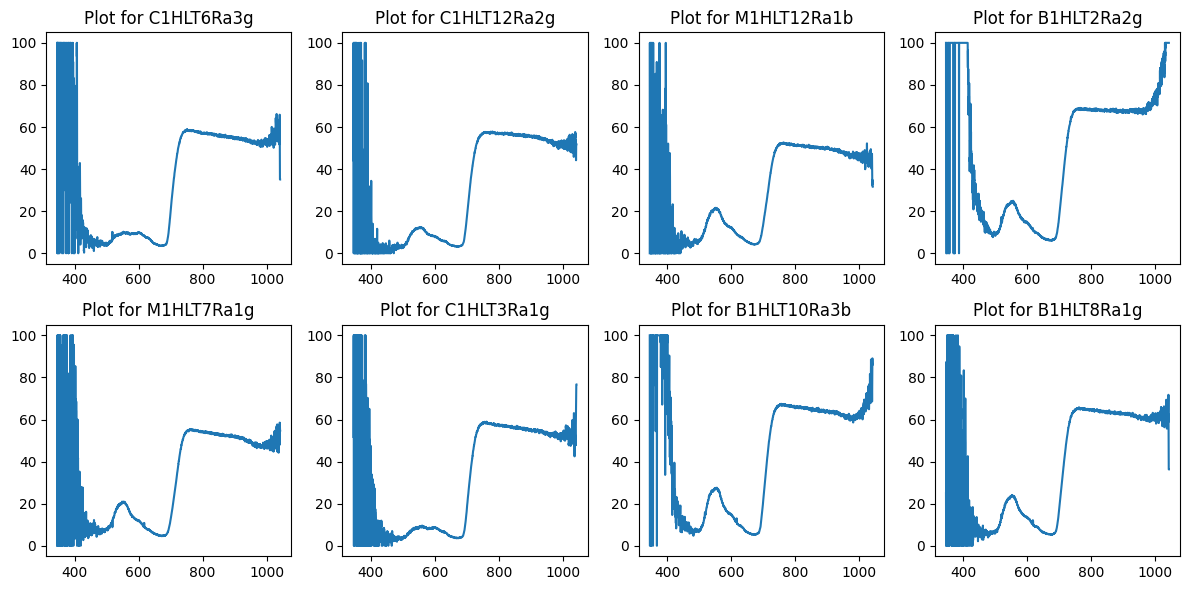

In [186]:
dataset = Custom_Dataset(data_path)
dataloader = Custom_Dataloader(dataset, batch_size= len(dataset), random= True)

x_data = next(iter(dataloader))
used_indices = dataloader.get_used_indices()



def sample_plots(x_range, y_range, indices):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.plot(x_range, y_range[i])
        ax.set_title(f'Plot for {dataset.get_label(indices[i])}')
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    sample_plots(dataloader.wavelength_range, x_data, used_indices)

## Custom Transform

In [182]:
class Transform(ABC):

    @abstractmethod
    def forward(self, *args, **kwargs):
        raise NotImplementedError()
        
    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

    def fit_transform(self, *args, **kwargs):
        return self.forward(*args, **kwargs)


if __name__ == '__main__':
    print(f'Testing Transform Abstract Class')

    try:
        transform = Transform()
        assert False, f'Cannot create from abstract method'
    except:
        pass

    print(f'Test passed')

Testing Transform Abstract Class
Test passed


## Range Clipping

In [194]:
class Range_Clip(Transform):

    def __init__(self,lower_bound, upper_bound=None):
        self.lower_bound = lower_bound
        if upper_bound is not None:
            assert lower_bound < upper_bound, f'lower bound({lower_bound}) should be lower than upper bound({upper_bound})'
        self.upper_bound = upper_bound
        self._tot_kept = 0
        self._done_flag = False
        self._tot_removed = 0


    def get_stats(self):
        assert self._done_flag, f'Run the forward method first, to pre-compute stats'
        return {'Kept': self._tot_kept, 'Removed': self._tot_removed}


    def forward(self, x_data, wavelength_range):
        mask = wavelength_range >= self.lower_bound
        if self.upper_bound is not None:
            mask = mask & (wavelength_range <= self.upper_bound)

        self._tot_kept += mask.sum()
        self._tot_removed += (~mask).sum()
        self._done_flag = True
        
        x_clipped = x_data[:, mask]
        wavelength_clipped = wavelength_range[mask]        
        assert x_clipped.shape[-1] == (wavelength_clipped.shape)[-1], f'Inconsistent shapes, corruption detected'  

        return x_clipped, wavelength_clipped
        
if __name__ == '__main__':
    print(f'Testing Range clipper')

    wavelength_range = dataloader.wavelength_range
    indices = dataloader.get_used_indices()
    
    ct = Range_Clip(400, 1000)
    x_clipped, wavelength_clipped = ct.fit_transform(x_data, wavelength_range)


    print(ct.get_stats())
    print(f'Test passed')


Testing Range clipper
{'Kept': np.int64(3135), 'Removed': np.int64(513)}
Test passed


## Visualization of clipped Ranges

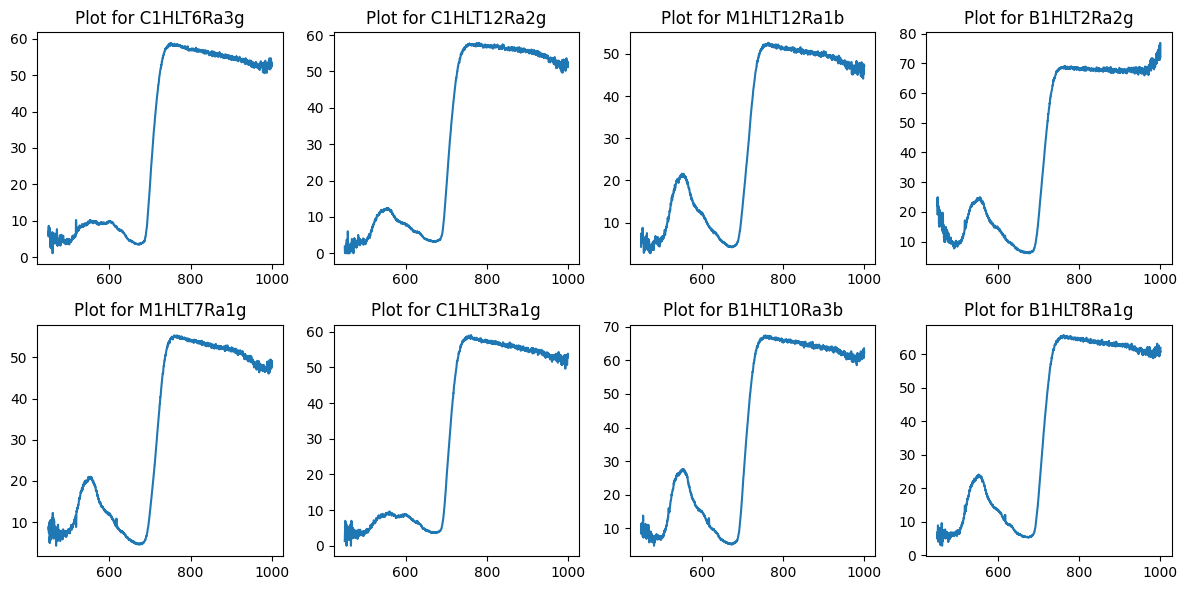

In [232]:
ct = Range_Clip(lower_bound=450, upper_bound=1000)
x_clipped, wavelength_clipped = ct.fit_transform(x_data, wavelength_range)

if __name__ == '__main__':
    sample_plots(wavelength_clipped, x_clipped, used_indices)

## Data Clustering Ochest

In [268]:
def xD_transform(x_data, n_components):
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_data)
    pca = PCA(n_components= n_components)
    return pca.fit_transform(x_scaled)

def train_ochest(x_data, n_components, n_clusters=3, random_state=42):
    pipeline = Pipeline([
        (f'scaler', StandardScaler()),
        (f'pca', PCA(n_components=100)),
        (f'kmeans', KMeans(n_clusters=n_clusters, random_state= random_state))
    ])

    pipeline.fit(x_data)
    labels = pipeline.named_steps['kmeans'].labels_
    centroids = pipeline.named_steps['kmeans'].cluster_centers_
    return {f'pipeline': pipeline, f'labels': labels, f'centriods': centroids }


if __name__ == '__main__':
    print('Testing Training Ochest')

    x_trans = xD_transform(x_clipped, 80)
    assert x_trans.shape[-1] == 80, f'Incompatible dimensions'
    test_1 = train_ochest(x_clipped,n_components= 50)

    print('Test passed')

Testing Training Ochest
Test passed


## Running Test cases

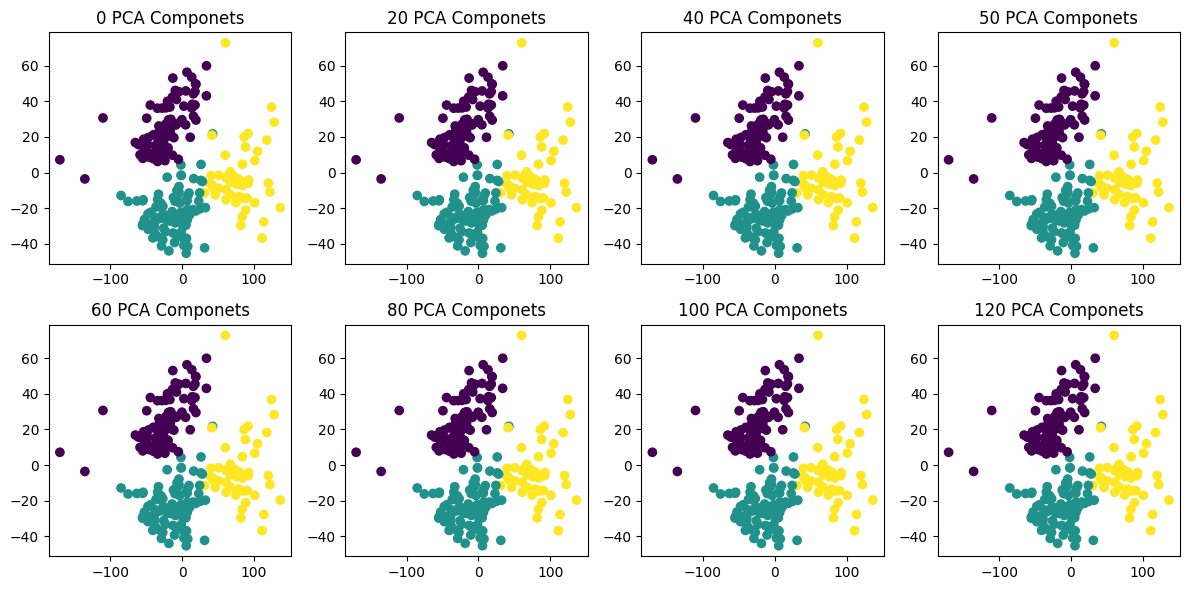

In [274]:
LOWER_BOUND = 450
UPPER_BOUND = 1000
PCA_TESTS =  [0, 20, 40, 50, 60, 80, 100, 120]


def run_test():
    dataset = Custom_Dataset(data_path)
    dataloader = Custom_Dataloader(dataset, batch_size= len(dataset), random= True)

    x_data = next(iter(dataloader))
    wavelength_range = dataloader.wavelength_range
    used_indices = dataloader.get_used_indices()

    
    ct = Range_Clip(lower_bound = LOWER_BOUND, upper_bound= UPPER_BOUND)
    x_clipped, wavelength_clipped = ct.fit_transform(x_data, wavelength_range)

    comp_1_buffer = []
    comp_2_buffer = []
    labels_buffer = []

    for i, n_components in enumerate(PCA_TESTS):
        test_ret = train_ochest(x_clipped, n_components, n_clusters=3)
        xd_trans = xD_transform(x_data, 2)

        comp_1_buffer.append(xd_trans[:, 0])
        comp_2_buffer.append(xd_trans[:, 1])
        labels_buffer.append(test_ret['labels'])

    scatter_gen(comp_1_buffer, comp_2_buffer, labels_buffer, PCA_TESTS)
        

def scatter_gen(comp_1_buffer, comp_2_buffer, labels, pca_ord):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.scatter(comp_1_buffer[i], comp_2_buffer[i],c=labels[i])
        ax.set_title(f'{pca_ord[i]} PCA Componets')
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    run_test()
